# Part 3 — AI Algorithm: predicting recorded arrest severity from context

This notebook reproduces the Person 3 analysis. A Random Forest predicts whether a recorded arrest is a Felony, Misdemeanor or Violation from contextual characteristics only — borough, precinct, age group, month, day of week, jurisdiction and coordinates. Fields that directly encode the charge (LAW_CODE, PD_DESC, OFNS_DESC) are excluded so the answer cannot leak into the inputs. Arrest records are recorded enforcement activity, not crime incidence.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from train_predictive_model import load_data, check_no_leakage, make_pipeline, SEVERITY_ORDER, SEVERITY_LABELS, CONTEXT_FEATURES, RANDOM_STATE

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'nypd_arrests_clean.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'part3'
FIGURE_DIR = PROJECT_ROOT / 'figures' / 'part3'
frame = load_data(DATA_PATH)
len(frame)

141870

## 1. Target and class balance

In [2]:
severity = frame['LAW_CAT_CD'].astype('string').str.strip().str.upper()
core = frame[severity.isin(SEVERITY_ORDER)].copy()
balance = severity[severity.isin(SEVERITY_ORDER)].value_counts().to_frame('records')
balance['share_pct'] = (100 * balance['records'] / balance['records'].sum()).round(2)
balance.index = [SEVERITY_LABELS[c] for c in balance.index]
print(f"Core labelled records: {len(core):,} of {len(frame):,}")
print(f"Excluded (missing or non-core codes): {len(frame) - len(core):,}")
display(balance)

Core labelled records: 140,476 of 141,870
Excluded (missing or non-core codes): 1,394


,records,share_pct
Misdemeanor,82929,59.03
Felony,55651,39.62
Violation,1896,1.35


Misdemeanor is the majority class at 59.0%, Violation is rare at 1.35%. A model that always predicts Misdemeanor scores 59.0% accuracy without learning anything, so the pipeline uses `class_weight="balanced"` and macro-F1 as the tuning metric, and the majority-class guess is the reference baseline.

## 2. Leakage-aware feature design

In [3]:
# Quick demonstration on a 4,000-record sample: adding charge-encoding fields inflates accuracy
from sklearn.model_selection import train_test_split
from train_predictive_model import build_feature_frame, CATEGORICAL_FEATURES, LEAKAGE_COLUMNS

sample = core.sample(4000, random_state=RANDOM_STATE)
y = sample['LAW_CAT_CD'].astype('string').str.strip().str.upper()
s_train, s_test, ys_train, ys_test = train_test_split(sample, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

variants = [
    ('Contextual', build_feature_frame(s_train), build_feature_frame(s_test), list(CATEGORICAL_FEATURES)),
    ('With charge fields', build_feature_frame(s_train, include_leakage=True), build_feature_frame(s_test, include_leakage=True),
     list(CATEGORICAL_FEATURES) + list(LEAKAGE_COLUMNS[:3])),
]
for name, features, test_features, cats in variants:
    pipe = make_pipeline(categorical=cats, model_params={'n_estimators': 50, 'max_depth': 15})
    pipe.fit(features, ys_train)
    acc = (pipe.predict(test_features) == ys_test.to_numpy()).mean()
    print(f"{name:18s} sample holdout accuracy: {acc:.3f}")

check_no_leakage(list(CONTEXT_FEATURES))
print('CONTEXT_FEATURES contain no leakage columns - verified.')

Contextual         sample holdout accuracy: 0.574
With charge fields sample holdout accuracy: 0.927
CONTEXT_FEATURES contain no leakage columns - verified.


The two models differ only in the input fields. Adding LAW_CODE, PD_CD and OFNS_DESC — fields that already encode the charge — pushes accuracy toward 1.0 without learning anything about context. The reported model deliberately excludes those fields; this exclusion is itself a design finding.

## 3. Holdout performance

In [4]:
metrics = json.loads((OUTPUT_DIR / 'model_metrics.json').read_text())
print(json.dumps({k: v for k, v in metrics.items() if k != 'confusion_matrix'}, indent=2))
display(pd.read_csv(OUTPUT_DIR / 'classification_report.csv'))
display(pd.read_csv(OUTPUT_DIR / 'confusion_matrix.csv'))

{
  "accuracy": 0.5915076879271071,
  "balanced_accuracy": 0.6514602418388499,
  "macro_f1": 0.497247675698993,
  "weighted_f1": 0.6003919250471642,
  "per_class": {
    "Felony": {
      "precision": 0.5339499036608863,
      "recall": 0.6224058934507232,
      "f1": 0.5747946569318841,
      "support": 11131
    },
    "Misdemeanor": {
      "precision": 0.695546019532406,
      "recall": 0.5668033281080429,
      "f1": 0.6246096604876752,
      "support": 16586
    },
    "Violation": {
      "precision": 0.1806853582554517,
      "recall": 0.7651715039577837,
      "f1": 0.2923387096774194,
      "support": 379
    }
  },
  "majority_baseline_accuracy": 0.5903331435079726,
  "leakage_accuracy": 0.9962984054669703,
  "leakage_macro_f1": 0.9927458761014725
}


,Unnamed: 0,precision,recall,f1-score,support
0,Felony,0.533950,0.622406,0.574795,11131
1,Misdemeanor,0.695546,0.566803,0.624610,16586
2,Violation,0.180685,0.765172,0.292339,379
3,accuracy,0.591508,0.591508,0.591508,0
4,macro avg,0.470060,0.651460,0.497248,28096
5,weighted avg,0.624580,0.591508,0.600392,28096


,Unnamed: 0,predicted_Felony,predicted_Misdemeanor,predicted_Violation
0,recorded_F,6928,4048,155
1,recorded_M,6025,9401,1160
2,recorded_V,22,67,290


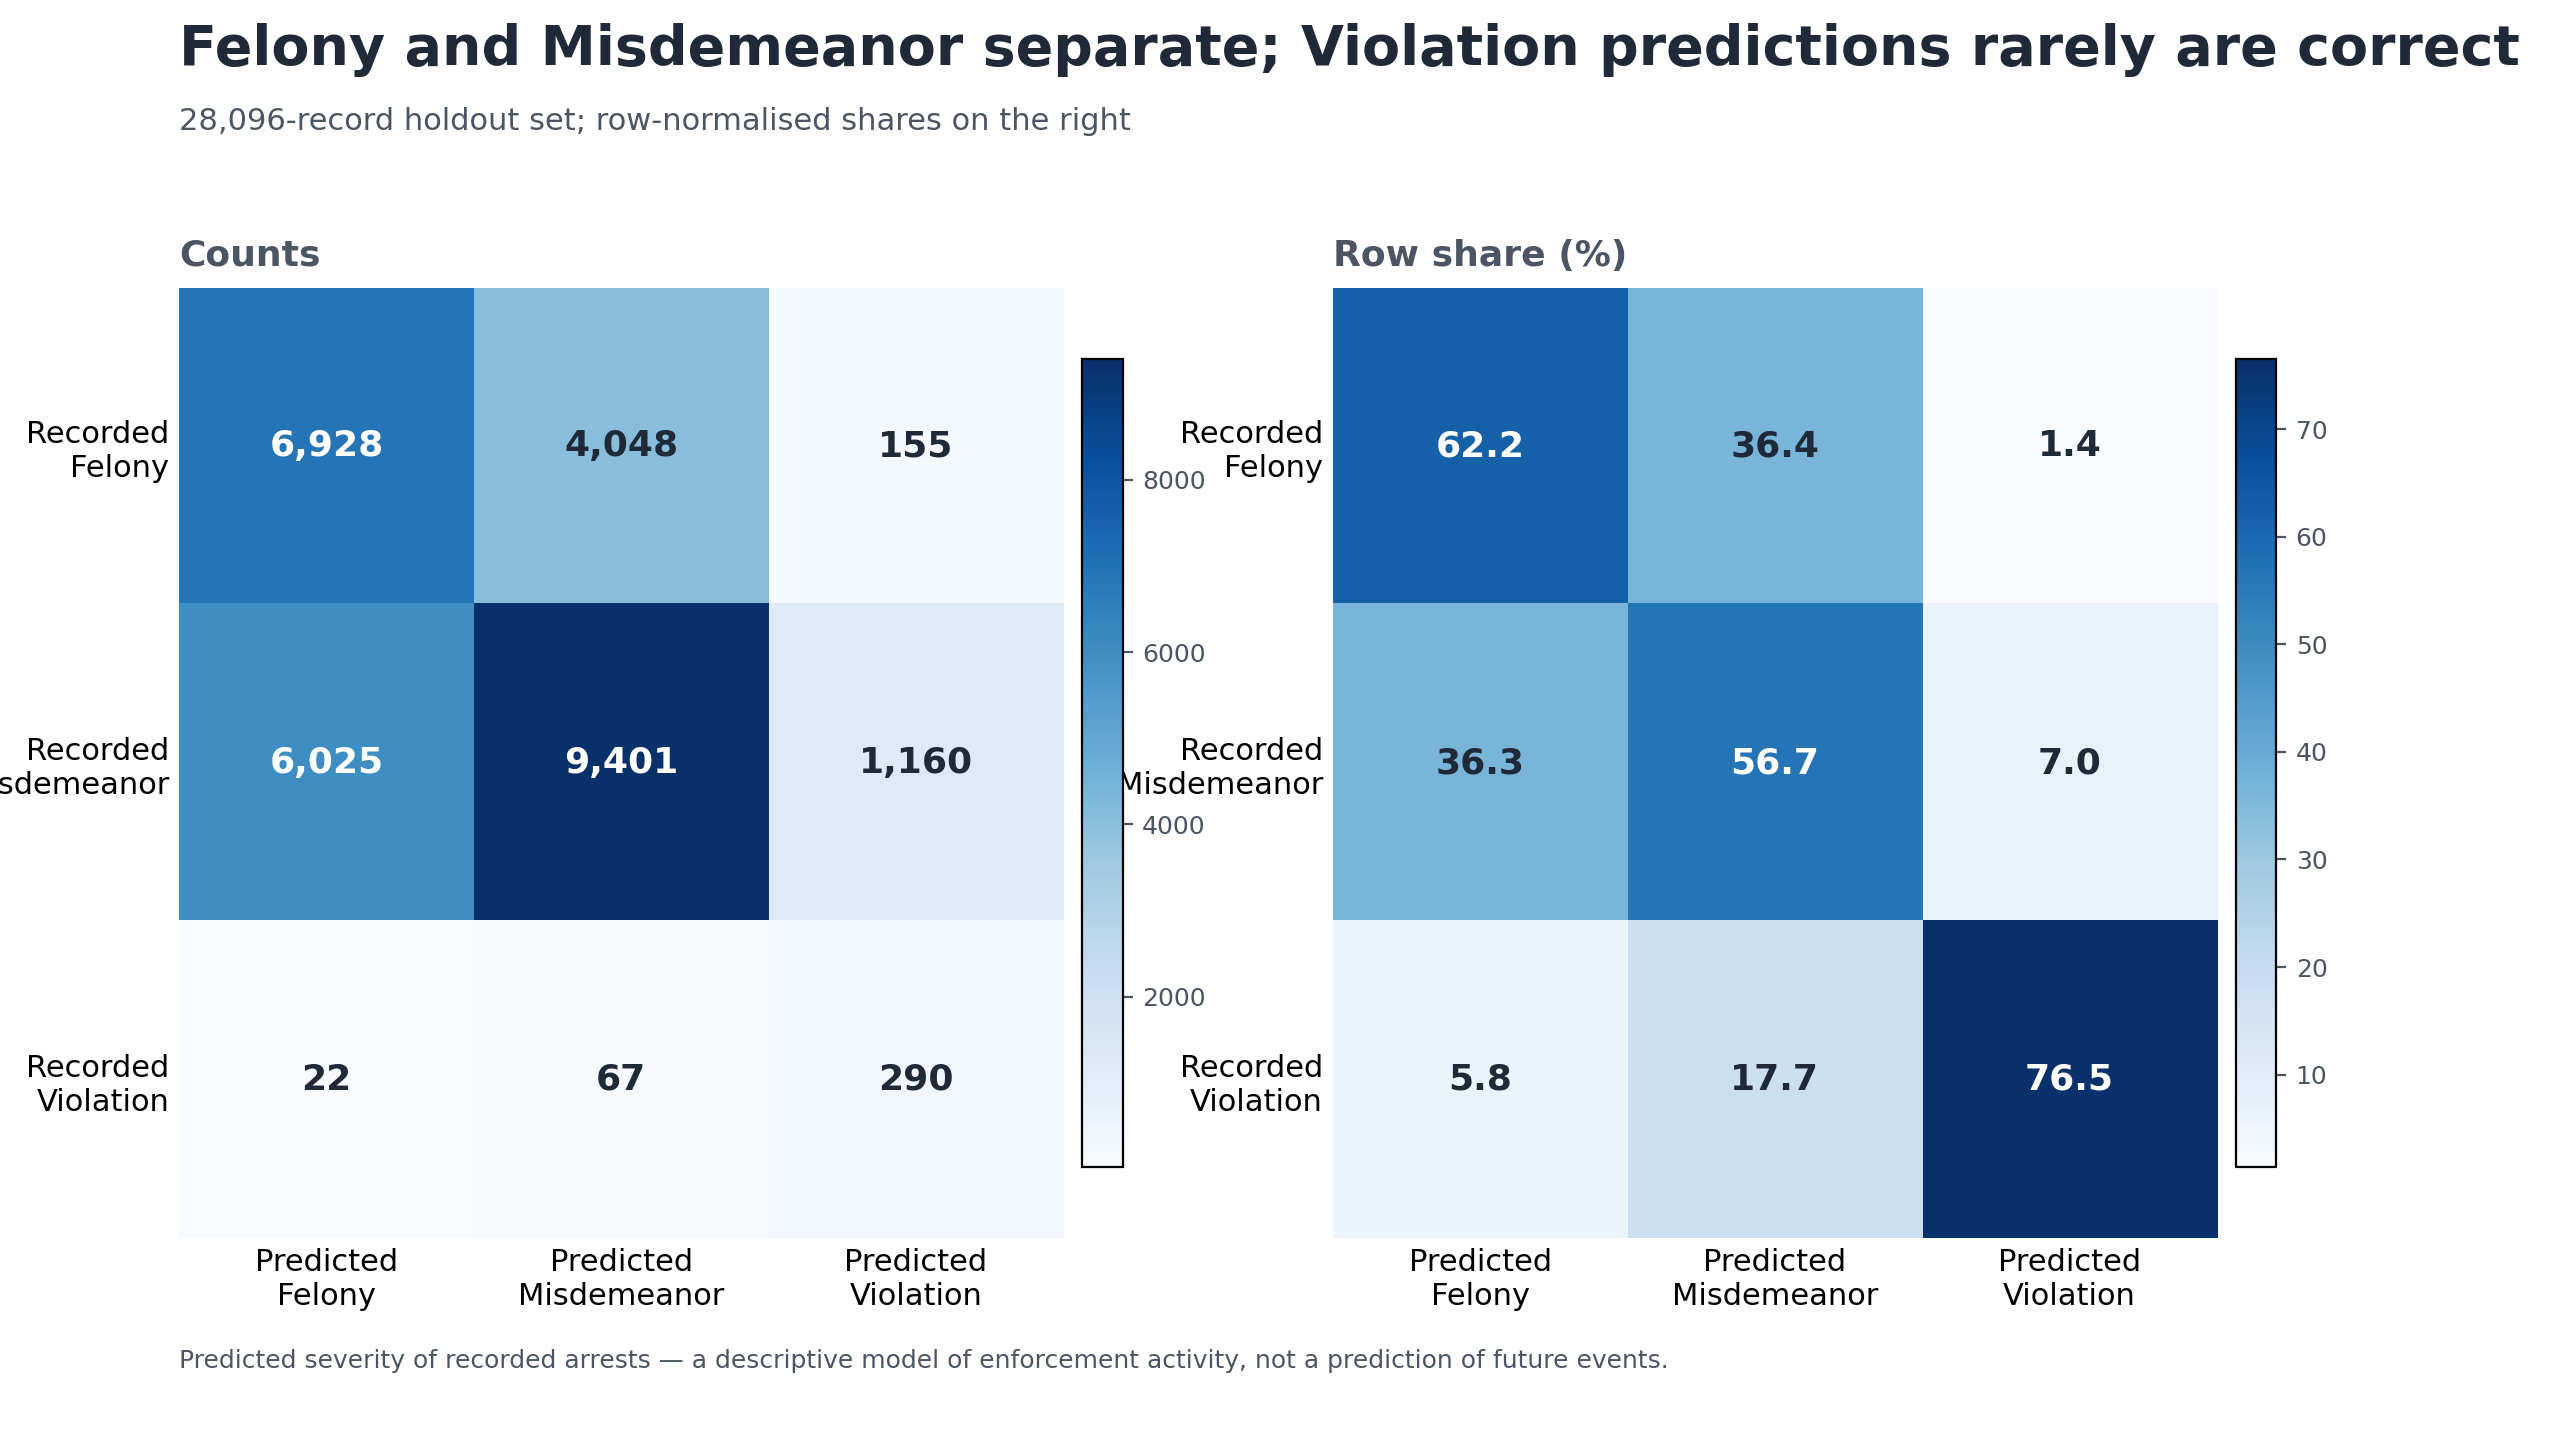

In [5]:
display(Image(filename=str(FIGURE_DIR / '01_confusion_matrix.png'), width=1000))

Felony and Misdemeanor records are separated reliably. Violation predictions are imprecise: with 1.35% prevalence and balanced class weights the model flags too many records as Violation, so precision is only 0.181 while recall is 0.765. That honest gap is reported rather than hidden by quoting overall accuracy alone.

## 4. Parameter fine tuning

In [6]:
grid = pd.read_csv(OUTPUT_DIR / 'grid_search_results.csv')
display(grid)
print((OUTPUT_DIR / 'best_parameters.json').read_text())

,n_estimators,max_depth,min_samples_leaf,mean_test_f1_macro,std_test_f1_macro,rank,mean_fit_seconds,mean_score_seconds
0,200,NaN,5,0.478665,0.004226,1,25.268825,0.311975
1,200,30.0,5,0.478021,0.004142,2,23.853890,0.306009
2,400,NaN,5,0.477505,0.003124,3,56.447017,0.552816
3,400,30.0,5,0.476752,0.004222,4,42.679525,0.429914
4,400,15.0,1,0.476596,0.005596,5,42.304957,0.441684
5,200,15.0,1,0.476573,0.005109,6,23.063542,0.276905
6,400,30.0,1,0.460705,0.014097,7,129.176818,0.474444
7,200,30.0,1,0.460598,0.014542,8,74.536770,0.430024
8,200,15.0,5,0.450682,0.007263,9,12.181753,0.225074
9,400,15.0,5,0.450022,0.006916,10,23.872275,0.402800


{
  "max_depth": null,
  "min_samples_leaf": 5,
  "n_estimators": 200,
  "best_cv_f1_macro": 0.4786650862454618
}


Twelve combinations of `n_estimators`, `max_depth` and `min_samples_leaf` were evaluated with stratified 5-fold cross-validation on a 30,000-row subsample of the training split, scored by macro-F1. The holdout set was never touched during tuning; the chosen parameters were then refitted on all 112,380 training records.

## 5. Explainability — feature importance

,feature,raw_feature,importance,share_pct
0,Jurisdiction,JURISDICTION_CODE,0.460514,46.051371
1,Latitude,LATITUDE,0.120660,12.065955
2,Precinct,ARREST_PRECINCT,0.114756,11.475578
3,Longitude,LONGITUDE,0.110247,11.024665
4,Month,MONTH,0.054438,5.443837
5,Day of week,DAY_OF_WEEK_NUM,0.053059,5.305946
6,Borough,ARREST_BORO,0.049349,4.934947
7,Age group,AGE_GROUP,0.036977,3.697702


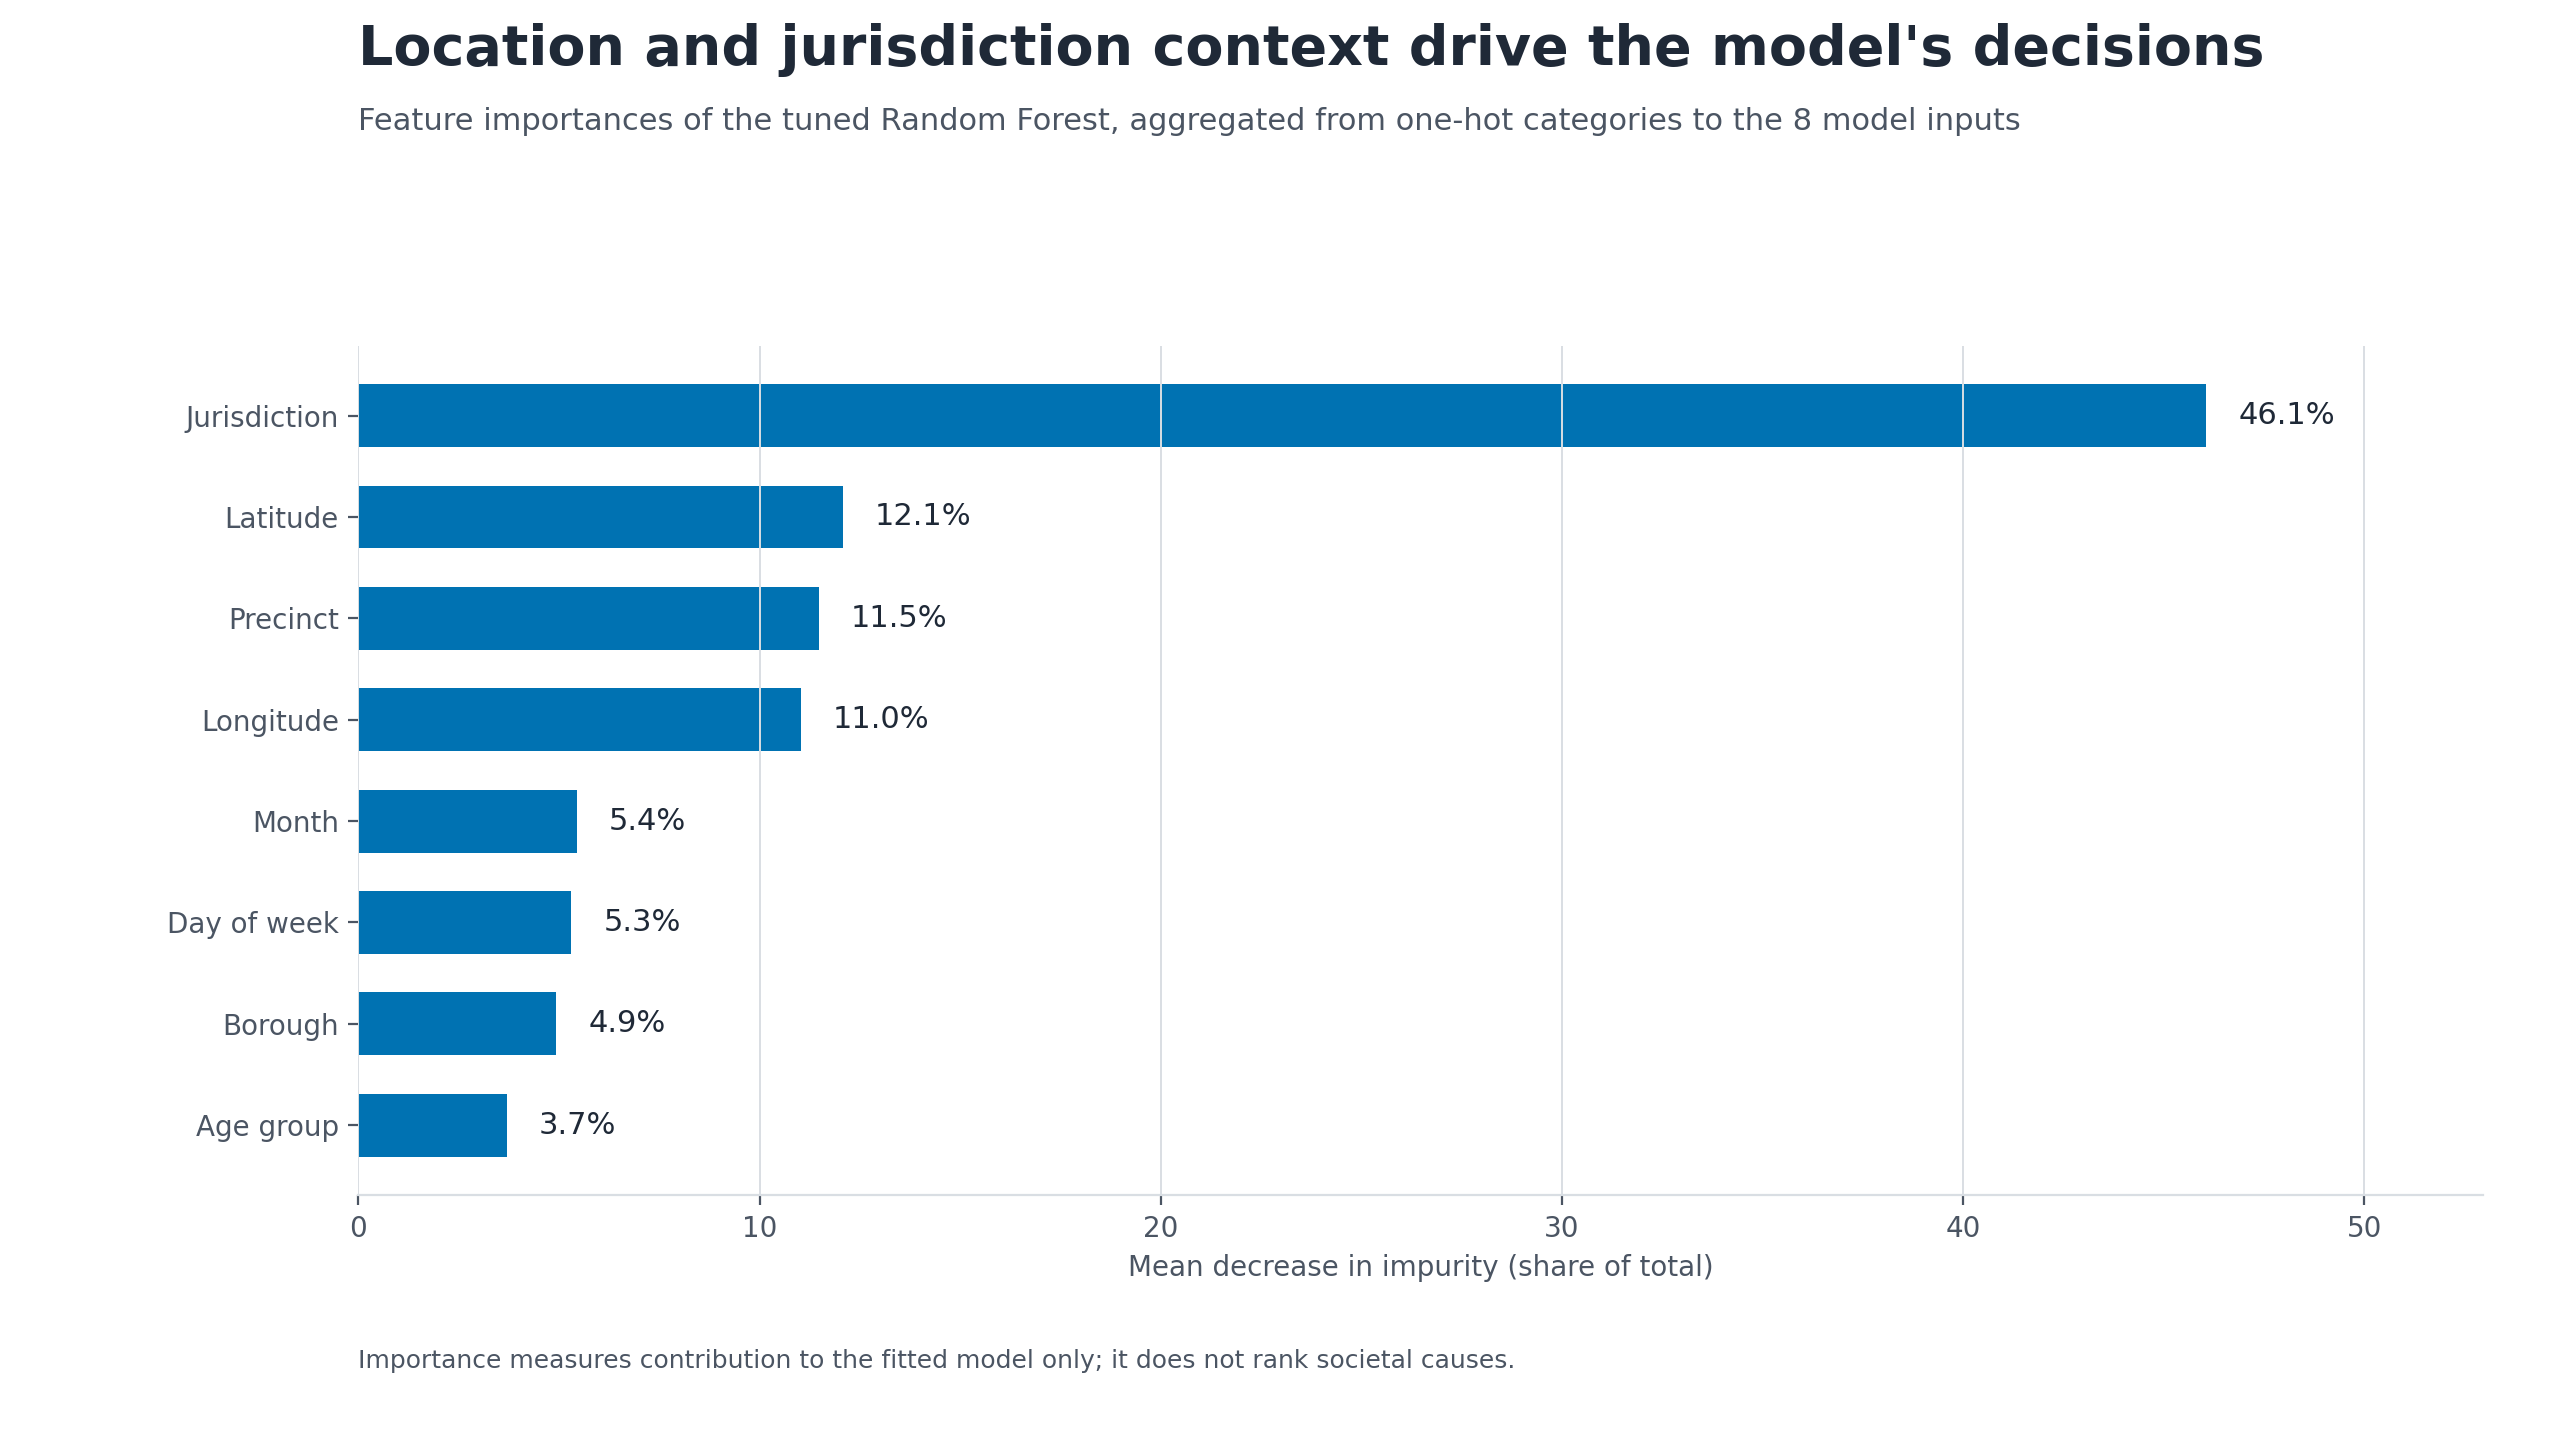

In [7]:
importance = pd.read_csv(OUTPUT_DIR / 'feature_importance.csv')
display(importance)
display(Image(filename=str(FIGURE_DIR / '02_feature_importance.png'), width=1000))

Mean decrease in impurity, aggregated from one-hot categories back to the eight model inputs. Importance ranks describe the fitted model's decisions; they do not rank societal mechanisms.

## 6. Explainability — partial dependence

,feature,category,p_felony
0,Age group,<18,0.617396
1,Age group,18-24,0.467976
2,Age group,25-44,0.445017
3,Age group,45-64,0.434610
4,Age group,65+,0.436612
5,Borough,Bronx,0.434328
6,Borough,Brooklyn,0.446911
7,Borough,Manhattan,0.435876
8,Borough,Queens,0.442499
9,Borough,Staten Island,0.440196


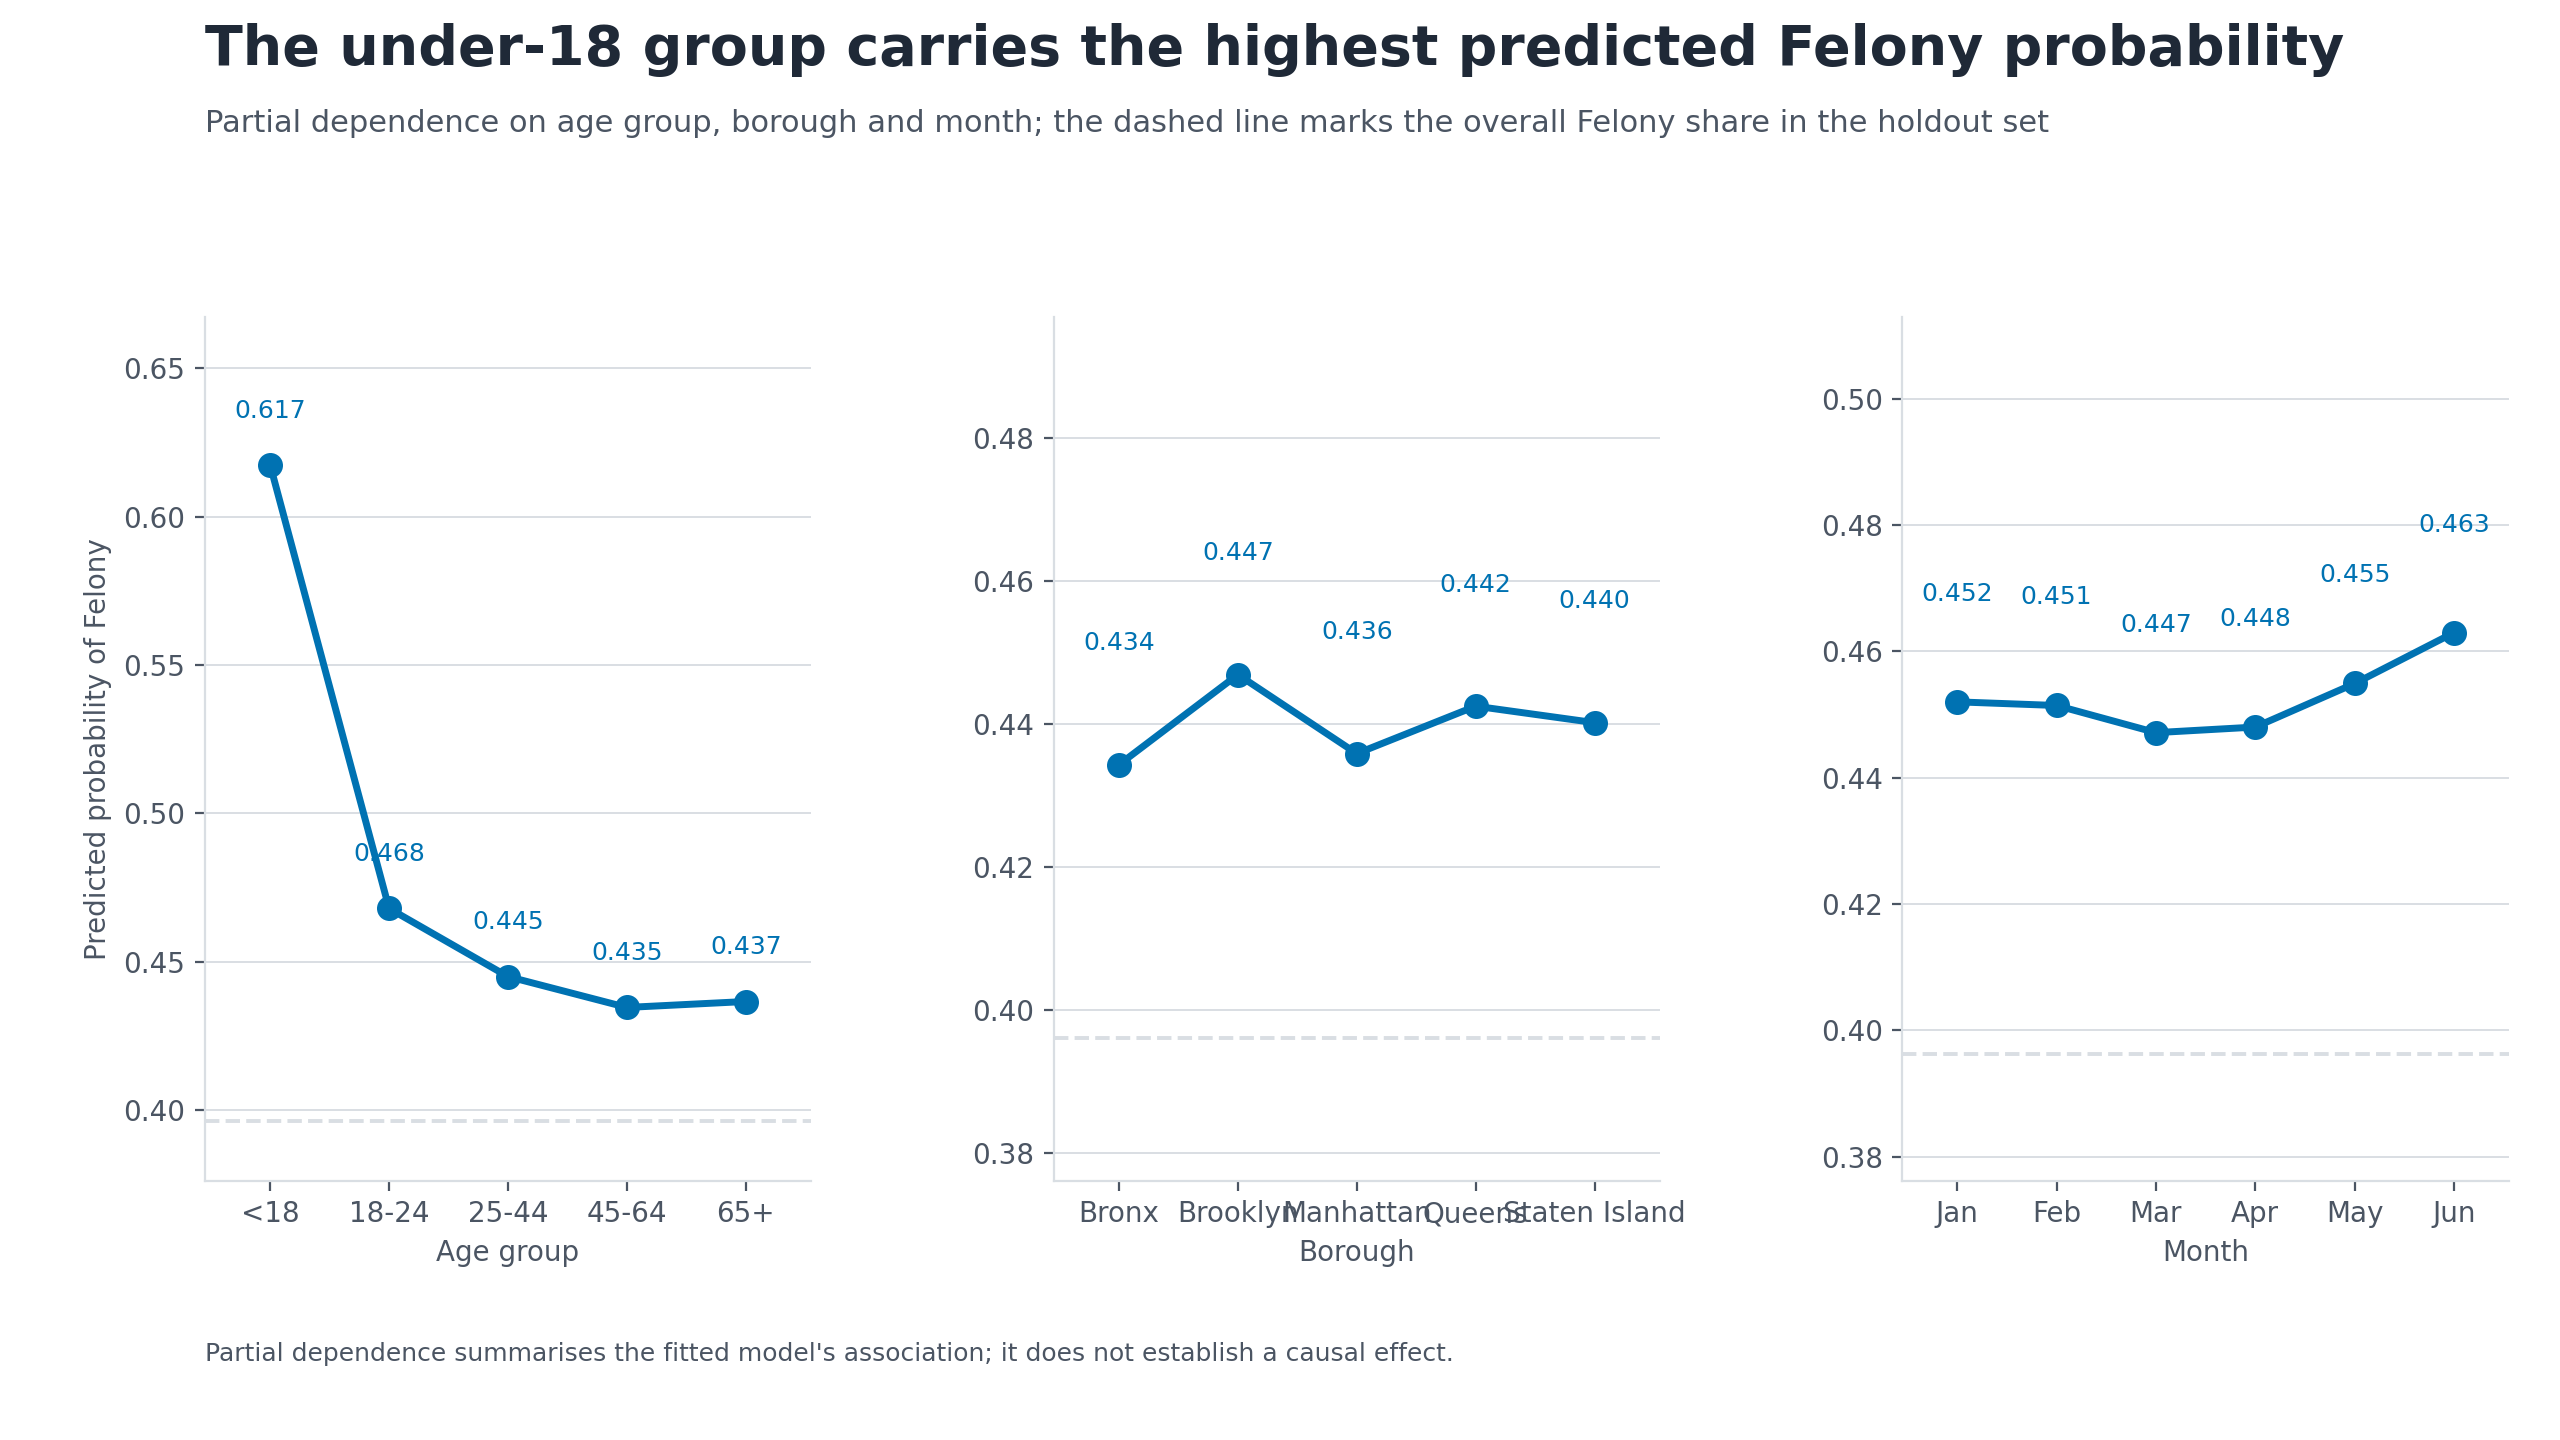

In [8]:
pdp = pd.read_csv(OUTPUT_DIR / 'pdp_values.csv')
display(pdp)
display(Image(filename=str(FIGURE_DIR / '03_partial_dependence.png'), width=1000))

The predicted Felony probability falls steadily from the under-18 group to older groups. Borough and month shift the probability only modestly. Partial dependence summarises the fitted model's association and does not establish a causal relationship.

## 7. Learning curve

,train_size,train_mean,train_std,val_mean,val_std
0,7492,0.615568,0.008412,0.465593,0.005673
1,24349,0.615129,0.001474,0.478930,0.004759
2,41206,0.617451,0.001145,0.485196,0.003664
3,58063,0.613786,0.002176,0.488796,0.001843
4,74920,0.615029,0.001617,0.494128,0.003391


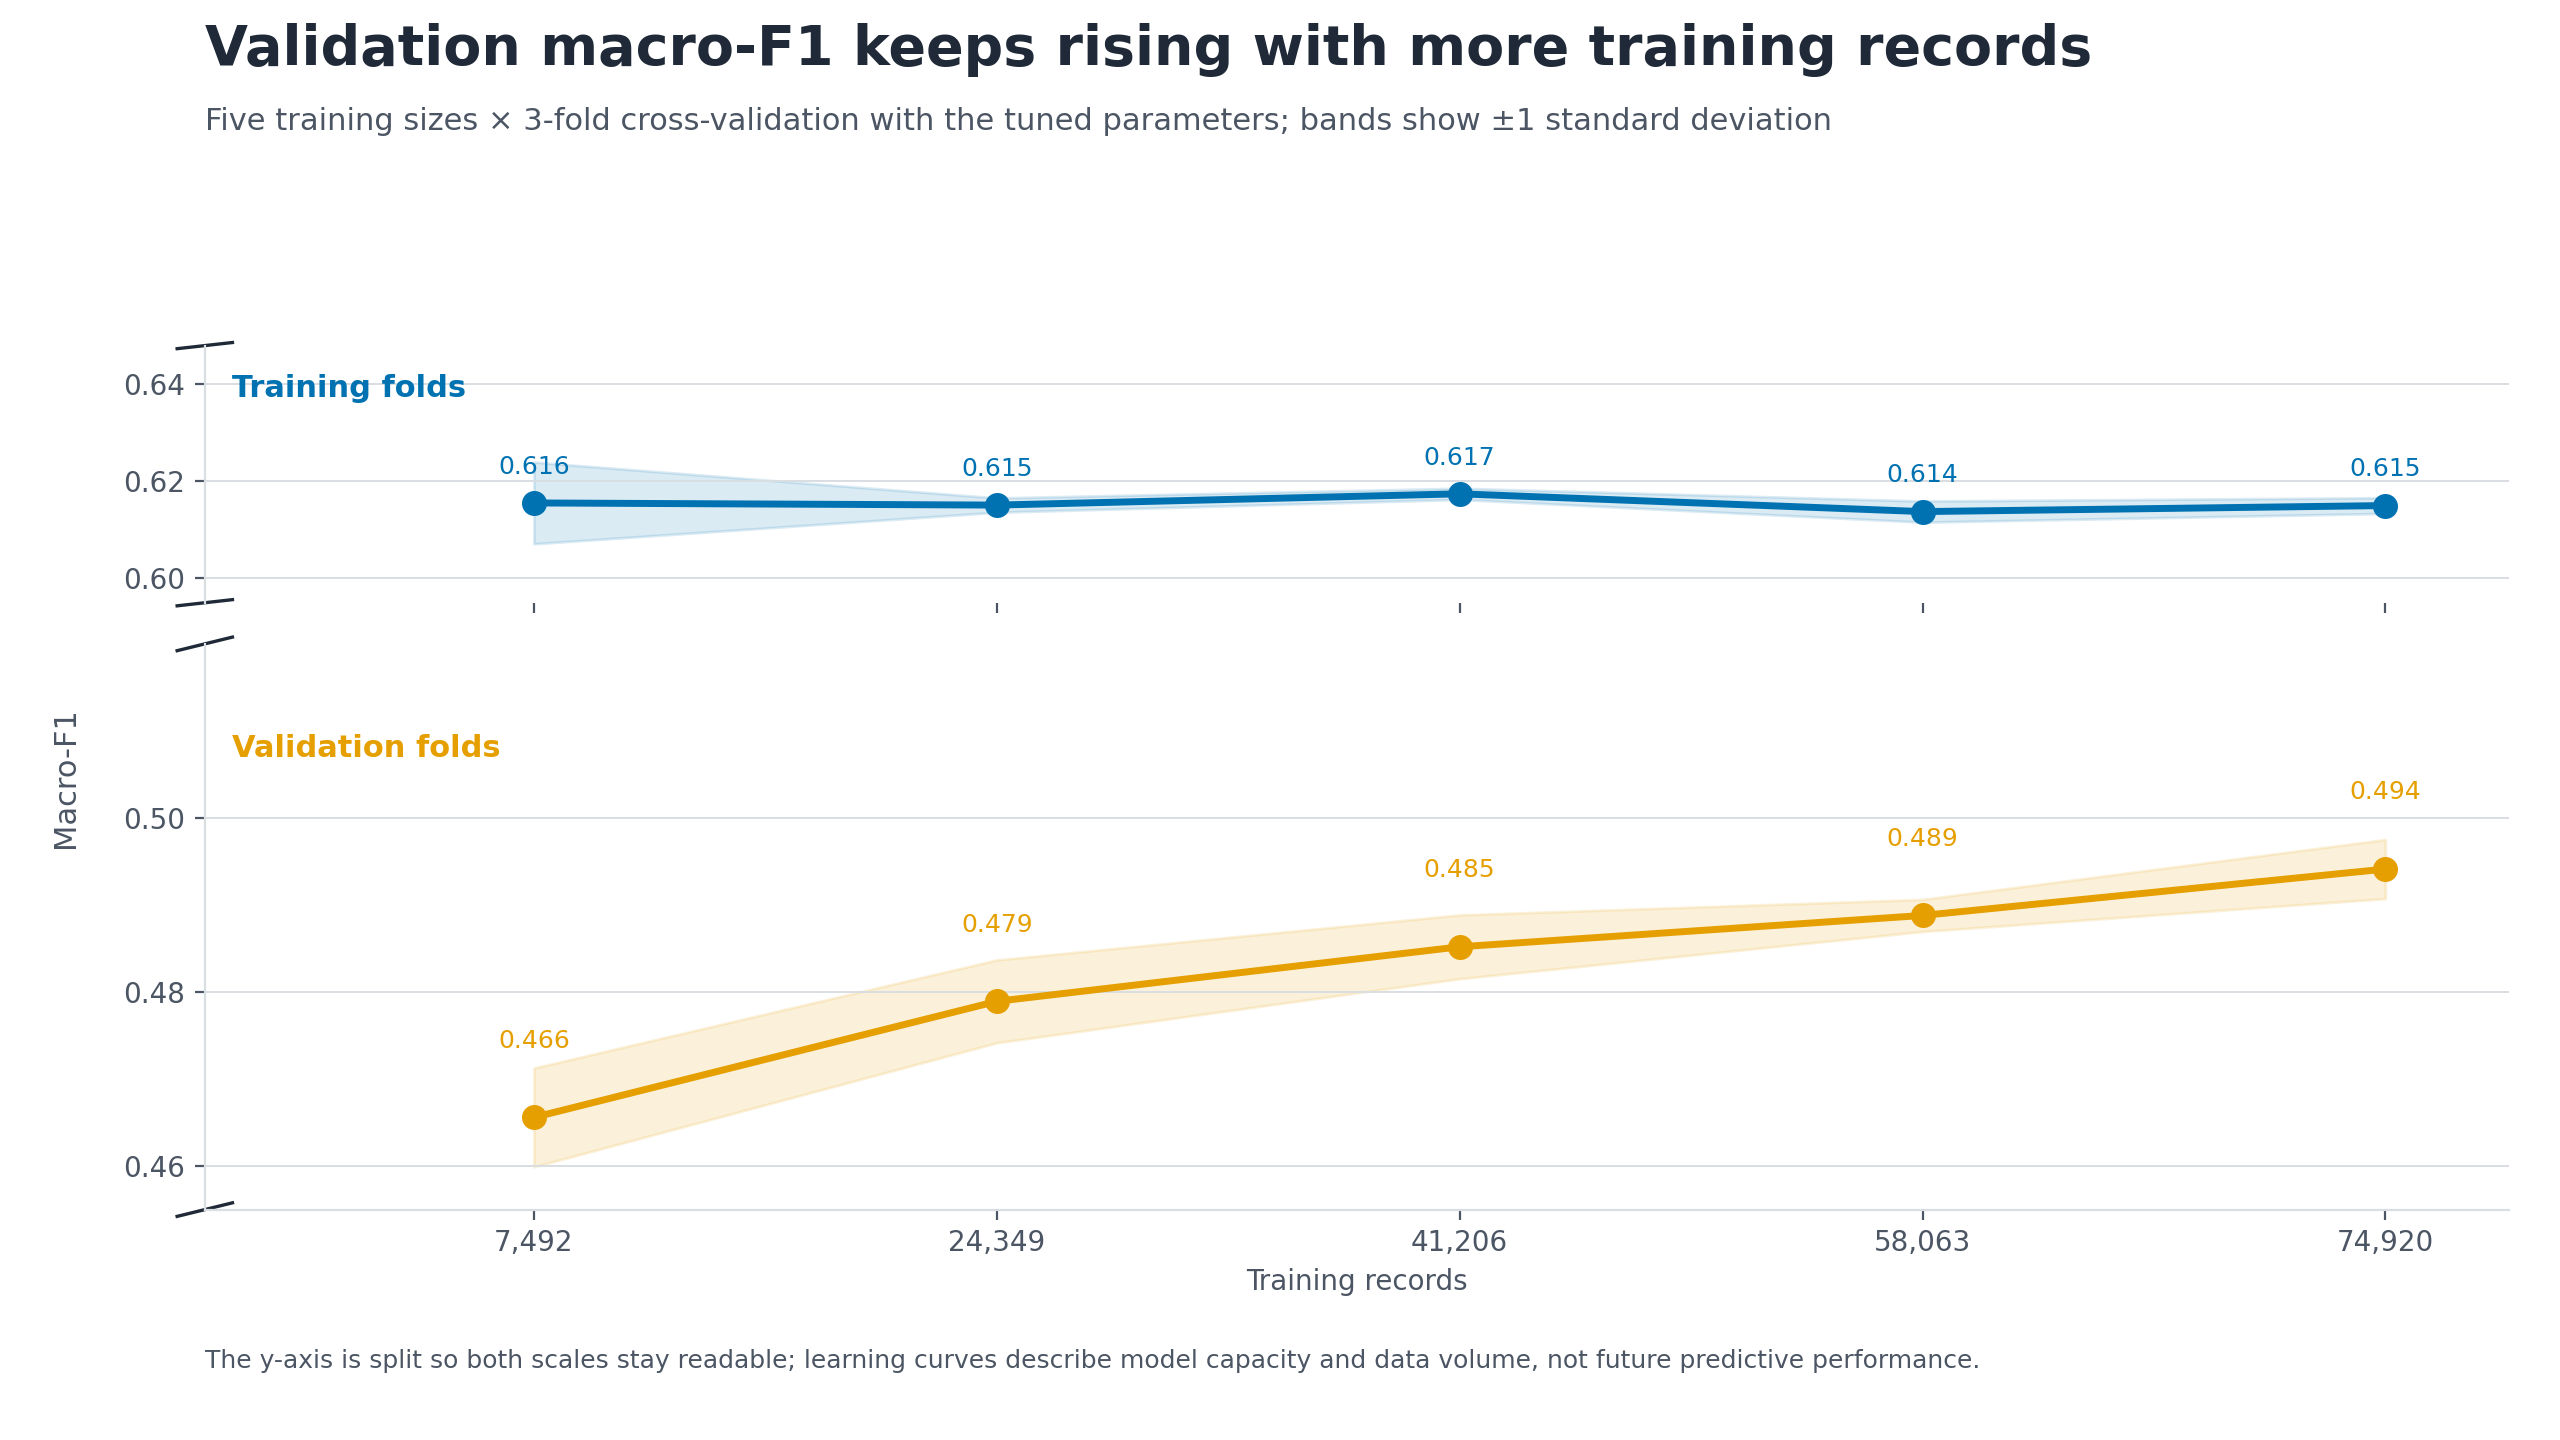

In [9]:
curve = pd.read_csv(OUTPUT_DIR / 'learning_curve.csv')
display(curve)
display(Image(filename=str(FIGURE_DIR / '04_learning_curve.png'), width=1000))

Validation macro-F1 keeps improving as training records are added, with no sign of a plateau at the largest training size of 74,920 records; the gap to the training score shows the model is not overfitting hard at these parameters.

## 8. The leakage warning

,model,accuracy,macro_f1
0,Majority baseline,0.590333,0.247467
1,Contextual model,0.591508,0.497248
2,Leakage-augmented model,0.996298,0.992746


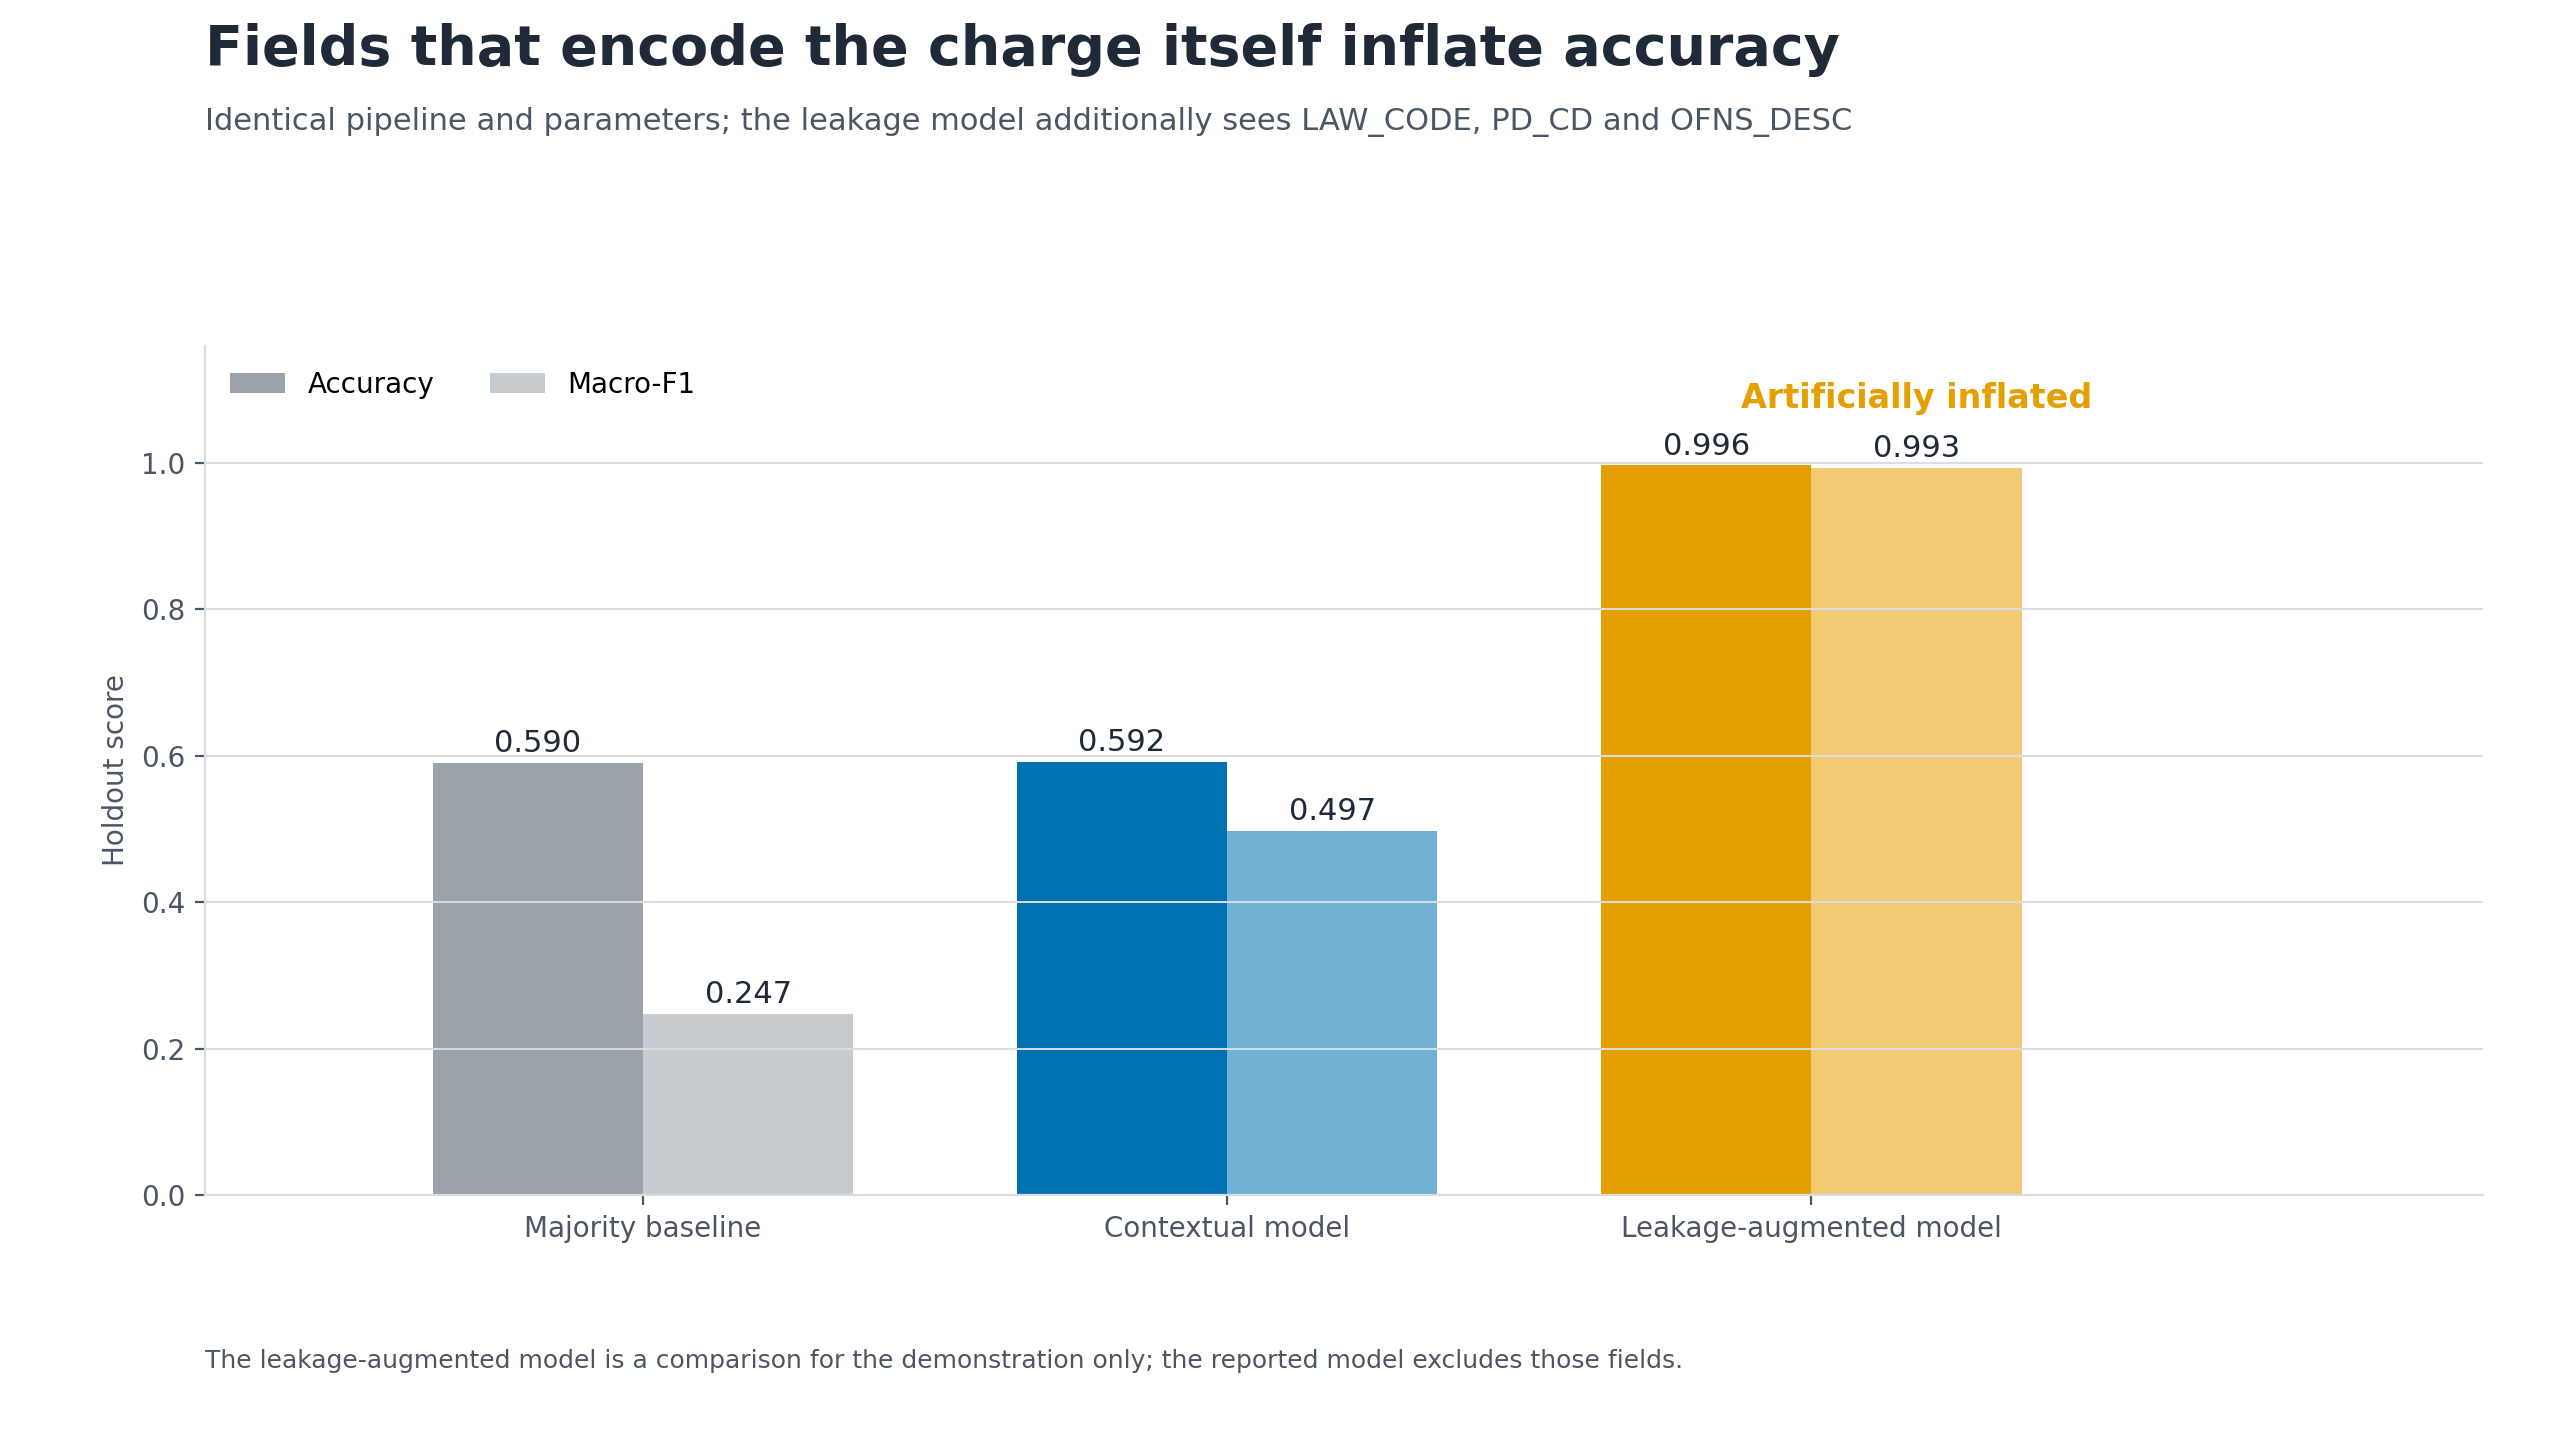

In [10]:
leakage = pd.read_csv(OUTPUT_DIR / 'leakage_comparison.csv')
display(leakage)
display(Image(filename=str(FIGURE_DIR / '05_leakage_comparison.png'), width=1000))

The leakage-augmented model exists only as a comparison: it shows how easily an artificially inflated accuracy could be presented as progress. Its score must not be cited as model performance.

## 9. Interpretation boundary

- Arrest records reflect policing, reporting and enforcement processes; the model describes recorded arrest activity, not crime incidence, and does not predict future events.
- The six-month snapshot (Jan–Jun 2026) is not evidence of longer-term stability.
- Feature importance and partial dependence describe the fitted model; they do not establish causal relationships.
- The Violation class is too rare for the model to separate; this limitation is stated alongside every score.